# Basic machine learning pipeline
## Employee Attrition Prediction — Logistic Regression 

**Dataset:** Employee Attrition Prediction Dataset  
**Models:** Logistic Regression 
**Goal:** Train and Predict if employee will leave the company or not

## Step 1: Load the Dataset

We load the dataset using pandas. The file uses a .xls extension but is stored as a CSV, so we use read_csv.

In [23]:
# Import the pandas library for data manipulation
import pandas as pd

# Load the dataset from the Downloads folder
# The file uses a .xls extension but is stored as a CSV, so we use read_csv
df = pd.read_csv('employee_attrition_prediction_dataset.xls')

# Preview the first 5 rows to confirm it loaded correctly
print(df.head())

# Check the total number of rows and columns
print(df.shape)

   Employee_ID   Age Department     Job_Level  Monthly_Salary  \
0            1  32.0         HR         Entry          3762.0   
1            2  47.0  Marketing         Entry         14081.0   
2            3  22.0         IT  Intermediate          8804.0   
3            4  25.0         HR  Intermediate         13462.0   
4            5  35.0         IT         Entry         13677.0   

   Years_At_Company  Job_Satisfaction  Work_Life_Balance Overtime  \
0                 7               3.0                  5      Yes   
1                 8               2.0                  2       No   
2                 4               5.0                  5       No   
3                 8               3.0                  1      Yes   
4                 9               1.0                  1       No   

   Training_Hours  Performance_Rating Remote_Work_Available Left_Company  
0              18                   4                   Yes           No  
1              39                   1       

## Step 2: Inspect the Dataset

We inspect the dataset to understand its structure, data types, missing values, and duplicates before making any changes.

In [26]:
# Display all column names in the dataset
print(df.columns)

# Show data types and non-null counts for each column
print(df.info())

# Display summary statistics for numerical columns
print(df.describe())

# Count missing values in each column
print(df.isnull().sum())

# Check for any duplicate rows
print(df.duplicated().sum())

Index(['Employee_ID', 'Age', 'Department', 'Job_Level', 'Monthly_Salary',
       'Years_At_Company', 'Job_Satisfaction', 'Work_Life_Balance', 'Overtime',
       'Training_Hours', 'Performance_Rating', 'Remote_Work_Available',
       'Left_Company'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            366 non-null    int64  
 1   Age                    360 non-null    float64
 2   Department             359 non-null    object 
 3   Job_Level              359 non-null    object 
 4   Monthly_Salary         360 non-null    float64
 5   Years_At_Company       366 non-null    int64  
 6   Job_Satisfaction       360 non-null    float64
 7   Work_Life_Balance      366 non-null    int64  
 8   Overtime               366 non-null    object 
 9   Training_Hours         366 non-null    int64  

## Step 3: Clean the Data

We remove duplicate rows and fill missing values.  
Numerical columns are filled with the median. Categorical columns are filled with the most frequent value.

In [29]:
# Check number of duplicate rows before cleaning
print("Duplicates before:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Confirm duplicates have been removed
print("Duplicates after:", df.duplicated().sum())

# Fill missing numerical values with the median of each column
numerical_columns = ['Age', 'Monthly_Salary', 'Job_Satisfaction']
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with the most frequent value (mode)
categorical_columns = ['Department', 'Job_Level', 'Remote_Work_Available']
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Confirm there are no more missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

Duplicates before: 6
Duplicates after: 0
Missing values after cleaning:
Employee_ID              0
Age                      0
Department               0
Job_Level                0
Monthly_Salary           0
Years_At_Company         0
Job_Satisfaction         0
Work_Life_Balance        0
Overtime                 0
Training_Hours           0
Performance_Rating       0
Remote_Work_Available    0
Left_Company             0
dtype: int64


## Step 4: Define Features and Target

The target variable is what the model predicts — Left_Company.  
The feature columns are the inputs the model learns from.  
Employee_ID is a row identifier with no predictive value and is excluded.

In [32]:
# Define the feature columns the model will learn from
# Employee_ID is excluded as it is just a row identifier
feature_columns = [
    'Age', 'Monthly_Salary', 'Years_At_Company', 'Job_Satisfaction',
    'Work_Life_Balance', 'Training_Hours', 'Performance_Rating',
    'Department', 'Job_Level', 'Overtime', 'Remote_Work_Available'
]

# Assign features to X and target to y
X = df[feature_columns]
y = df['Left_Company']

# Encode the target variable: No → 0, Yes → 1
y = y.map({'No': 0, 'Yes': 1})

# Confirm the shapes of X and y
print("X shape:", X.shape)
print("y shape:", y.shape)

# Check the class distribution of the target variable
print(y.value_counts())

X shape: (360, 11)
y shape: (360,)
Left_Company
0    330
1     30
Name: count, dtype: int64


## Step 5: Train/Test Split

We split the data into 80% training and 20% testing.  
stratify=y ensures both splits maintain the same class balance.

In [35]:
# Import the train/test split function
from sklearn.model_selection import train_test_split

# Split the data — 80% for training, 20% for testing
# random_state=42 ensures reproducibility
# stratify=y maintains the same class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Confirm the size of each split
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (288, 11)
X_test shape: (72, 11)
y_train shape: (288,)
y_test shape: (72,)


## Step 6: Preprocessing

Numerical features are scaled using StandardScaler.  
Categorical features are encoded using OneHotEncoder.  
The preprocessor is fitted on training data only and applied to the test set.

In [38]:
# Import the necessary preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define which columns are numerical and which are categorical
numerical_features = [
    'Age', 'Monthly_Salary', 'Years_At_Company', 'Job_Satisfaction',
    'Work_Life_Balance', 'Training_Hours', 'Performance_Rating'
]

categorical_features = ['Department', 'Job_Level', 'Overtime', 'Remote_Work_Available']

# Build the preprocessor:
# - StandardScaler normalises numerical features to the same scale
# - OneHotEncoder converts categorical features into binary columns
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Fit the preprocessor on training data only, then apply to both sets
# This prevents data leakage from the test set
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Confirm the new shapes after preprocessing
print("X_train after preprocessing:", X_train_preprocessed.shape)
print("X_test after preprocessing:", X_test_preprocessed.shape)

X_train after preprocessing: (288, 21)
X_test after preprocessing: (72, 21)


## Step 7: Train and Evaluate — Logistic Regression

We train a Logistic Regression model and evaluate it using accuracy, precision, recall, F1 score, and a confusion matrix.

=== Logistic Regression ===
Accuracy: 0.9305555555555556
Precision: 0.6666666666666666
Recall: 0.3333333333333333
F1 Score: 0.4444444444444444

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.94      0.98      0.96        66
        Left       0.67      0.33      0.44         6

    accuracy                           0.93        72
   macro avg       0.80      0.66      0.70        72
weighted avg       0.92      0.93      0.92        72



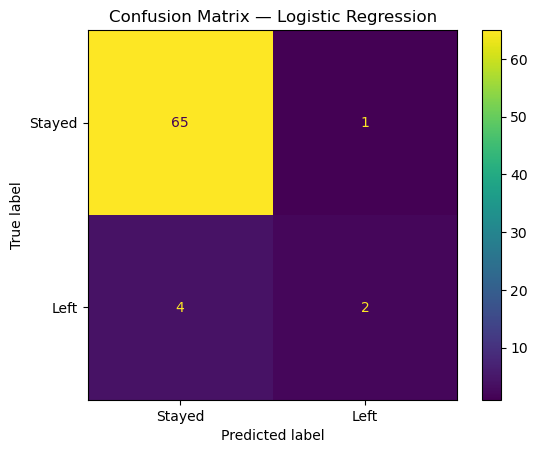

In [41]:
# Import Logistic Regression and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Initialise and train the Logistic Regression model
# max_iter=1000 ensures the model has enough iterations to converge
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_preprocessed, y_train)

# Use the trained model to make predictions on the test set
y_pred_lr = lr_model.predict(X_test_preprocessed)

# Print individual evaluation metrics
print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

# Print the full classification report with per-class metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Left']))

# Plot the confusion matrix to visualise prediction results
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Stayed', 'Left']).plot()
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

## Task 2: Results Interpretation


## 1. What the model is trying to predict
The model is designed to predict **employee attrition**, meaning whether an employee will:

- Stay at the company  
- Leave the company  

This is a binary classification problem.



## 2. Dataset used
The dataset used is the **Employee Attrition Prediction Dataset**, which contains employee-related information such as demographics, job role, satisfaction, and work conditions.

It is used to analyze patterns that may lead to employee turnover.


## 3. Features and target selected

### Features (X)
The input variables include employee attributes such as:

- Age  
- Job role  
- Monthly income  
- Work environment satisfaction  
- Years at company  
- Overtime status  
- Job level  
- Other HR-related features  

### Target (y)
- **Attrition (binary label):**
  - `Stayed`
  - `Left`


## 4. Results obtained (Logistic Regression model)

- **Accuracy:** 93.06%  
- **Precision:** 66.67%  
- **Recall:** 33.33%  
- **F1-score:** 44.44%  

### Interpretation:
- The model performs well at predicting employees who **stay**
- It struggles to correctly identify employees who **leave**


## 5. One limitation of the model or dataset

A major limitation is **class imbalance**:

- Only 6 employees left vs 66 who stayed  
- This causes the model to bias toward predicting "Stayed"

As a result:
- High overall accuracy  
- Poor performance on detecting employees who leave (minority class)